In [2]:
import control as ctrl
import matplotlib.pyplot as plt
import math
import numpy as np

## Ej 5

In [3]:
Aa = np.array([
    [-0.25, -2.00,  0.0, 0.0],
    [ 0.08, -0.35,  0.0, 0.0],
    [ 0.00,  1.00,  0.0, 0.0],
    [ 0.00,  0.00, -1.0, 0.0]
])

Ba = np.array([
    [0.0],
    [0.62],
    [0.0],
    [0.0]
])

n = Aa.shape[0]

Mc = np.hstack([
    Ba,
    Aa @ Ba,
    np.linalg.matrix_power(Aa, 2) @ Ba,
    np.linalg.matrix_power(Aa, 3) @ Ba
])

phi_A = (
    np.linalg.matrix_power(Aa, 4)
    + 9.0 * np.linalg.matrix_power(Aa, 3)
    + 29.75 * np.linalg.matrix_power(Aa, 2)
    + 42.75 * Aa
    + 22.5 * np.eye(n)
)

e_n = np.array([[0.0, 0.0, 0.0, 1.0]])

Ka = e_n @ np.linalg.inv(Mc) @ phi_A
Aa_lc = Aa - Ba @ Ka

print("\nKa:")
print(Ka)
print("\nMatriz A a lazo cerrado:")
print(Aa_lc)
print("\nPolos a lazo cerrado:")
print(np.linalg.eigvals(Aa_lc))


Ka:
[[-174.51814516   13.5483871  -304.83870968 -145.16129032]]

Matriz A a lazo cerrado:
[[ -0.25     -2.        0.        0.     ]
 [108.28125  -8.75    189.       90.     ]
 [  0.        1.        0.        0.     ]
 [  0.        0.       -1.        0.     ]]

Polos a lazo cerrado:
[-3.  -2.5 -2.  -1.5]


## EJ 6

In [4]:
Ca = np.array([[0.0, 0.0, 1.0, 0.0]])
Da = np.array([[0.0]])
Br = np.array([[0.0], [0.0], [0.0], [1.0]])

# La referencia entra en el integrador: x4_dot = psi_ref - psi.
sistema_lc = ctrl.ss(Aa_lc, Br, Ca, Da)
Gs = ctrl.ss2tf(sistema_lc)

print("G(s) a lazo cerrado:")
print(Gs)

G(s) a lazo cerrado:
<TransferFunction>: sys[1]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        8.882e-15 s^3 + 90 s + 22.5
  ----------------------------------------
  s^4 + 9 s^3 + 29.75 s^2 + 42.75 s + 22.5


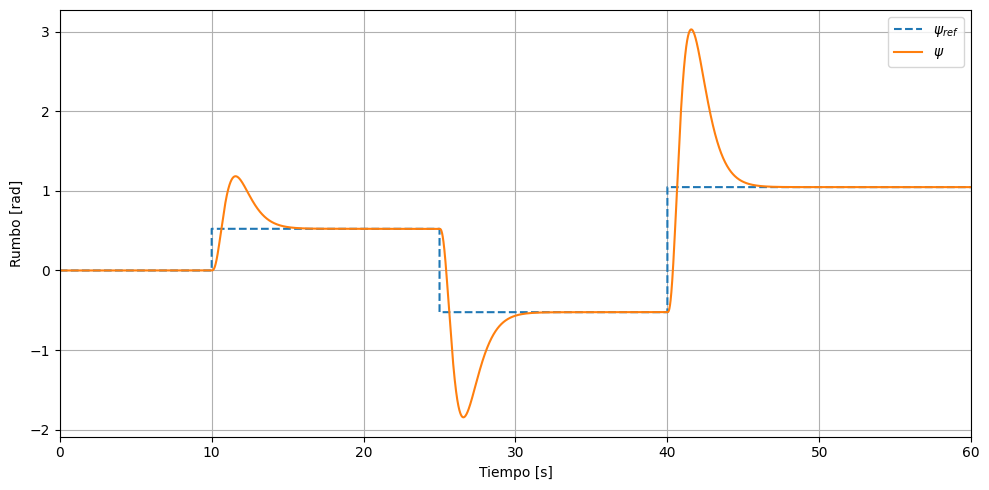

In [5]:
Tf = 60.0
dt = 0.01
t = np.arange(0.0, Tf + dt, dt)

psi_ref = np.select(
    [t < 10.0, t < 25.0, t < 40.0],
    [0.0, np.pi / 6.0, -np.pi / 6.0],
    default=np.pi / 3.0,
)

respuesta = ctrl.forced_response(sistema_lc, T=t, U=psi_ref)
psi = np.asarray(respuesta.outputs).squeeze()

plt.figure(figsize=(10, 5))
plt.step(t, psi_ref, where="post", linestyle="--", label=r"$\psi_{ref}$")
plt.plot(t, psi, label=r"$\psi$")
plt.xlabel("Tiempo [s]")
plt.ylabel("Rumbo [rad]")
plt.xlim(0.0, Tf)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Ej 7

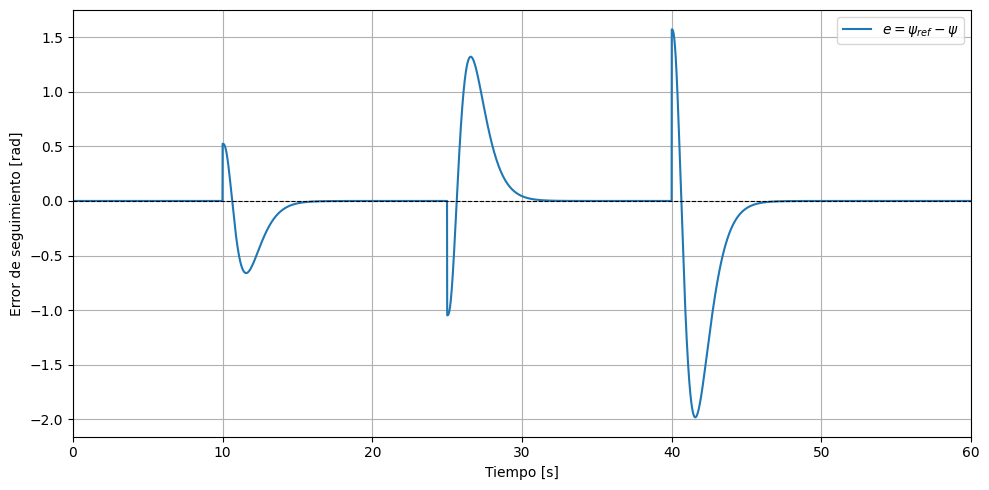

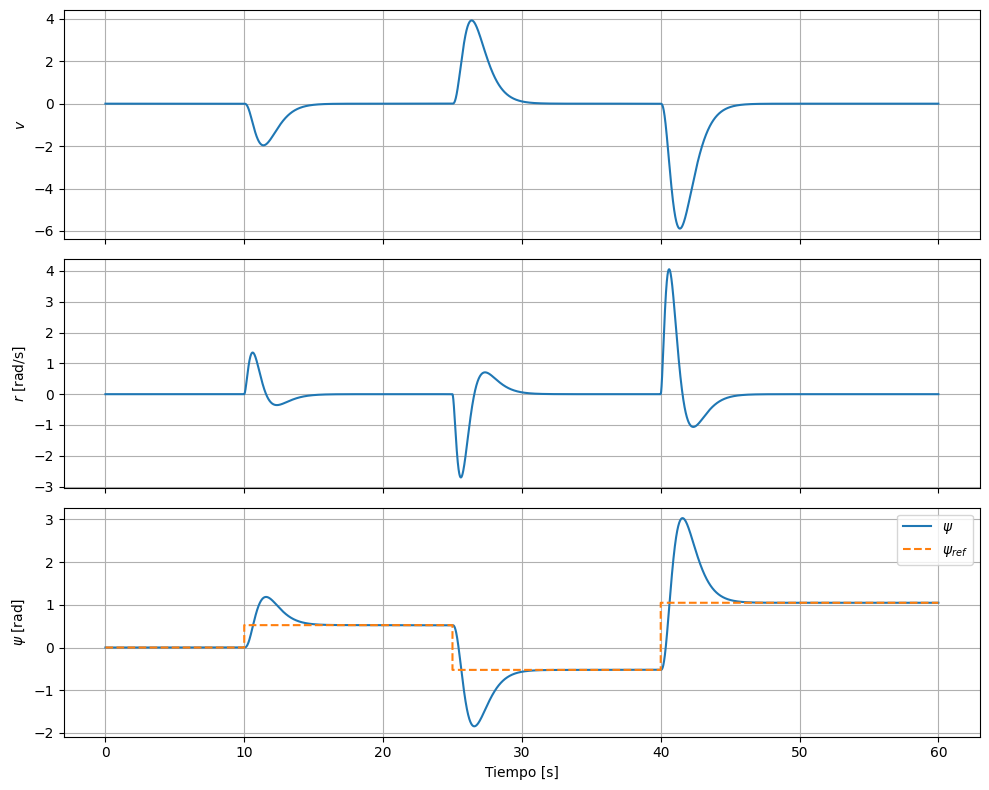

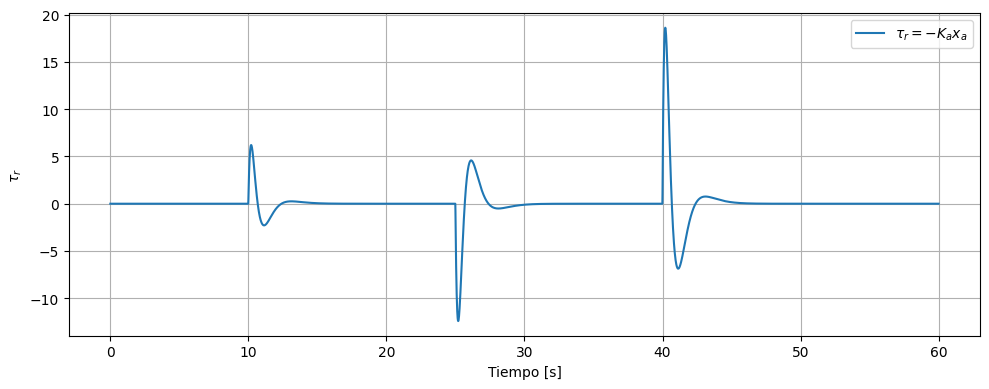

In [6]:
Tf = 60.0
dt = 0.01
t = np.arange(0.0, Tf + dt, dt)

psi_ref = np.select(
    [t < 10.0, t < 25.0, t < 40.0],
    [0.0, np.pi / 6.0, -np.pi / 6.0],
    default=np.pi / 3.0,
)

respuesta = ctrl.forced_response(sistema_lc, T=t, U=psi_ref)
psi = np.asarray(respuesta.outputs).squeeze()
x = np.asarray(respuesta.states)
v = x[0, :]
r = x[1, :]
psi = x[2, :]
x_integral = x[3, :]

err = psi_ref - psi
t_r = np.asarray(-Ka @ x).squeeze()

plt.figure(figsize=(10, 5))
plt.plot(t, err, label=r"$e=\psi_{ref}-\psi$")
plt.axhline(0.0, color="black", linestyle="--", linewidth=0.8)

plt.xlabel("Tiempo [s]")
plt.ylabel("Error de seguimiento [rad]")
plt.xlim(0.0, Tf)
plt.grid(True)
plt.legend()
plt.tight_layout()

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

ax[0].plot(t, v)
ax[0].set_ylabel(r"$v$")
ax[0].grid(True)

ax[1].plot(t, r)
ax[1].set_ylabel(r"$r$ [rad/s]")
ax[1].grid(True)

ax[2].plot(t, psi, label=r"$\psi$")
ax[2].step(t, psi_ref, where="post", linestyle="--",
           label=r"$\psi_{ref}$")
ax[2].set_ylabel(r"$\psi$ [rad]")
ax[2].set_xlabel("Tiempo [s]")
ax[2].grid(True)
ax[2].legend()

plt.figure(figsize=(10, 4))
plt.plot(t, t_r, label=r"$\tau_r=-K_ax_a$")
plt.xlabel("Tiempo [s]")
plt.ylabel(r"$\tau_r$")
plt.grid(True)
plt.legend()
plt.tight_layout()

fig.tight_layout()


plt.show()

# Parte B

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

## Ej 2

In [10]:
u0 = 2.0

v_interp = interp1d(t, v, kind="linear", fill_value="extrapolate")
psi_interp = interp1d(t, psi, kind="linear", fill_value="extrapolate")

def cinematica_xy(ti, pos):
    X, Y = pos

    v_t = float(v_interp(ti))
    psi_t = float(psi_interp(ti))

    X_dot = u0 * np.cos(psi_t) - v_t * np.sin(psi_t)
    Y_dot = u0 * np.sin(psi_t) + v_t * np.cos(psi_t)

    return [X_dot, Y_dot]

pos0 = [0.0, 0.0]

sol_xy = solve_ivp(
    cinematica_xy,
    [t[0], t[-1]],
    pos0,
    t_eval=t
)

X = sol_xy.y[0]
Y = sol_xy.y[1]


## Ej 3

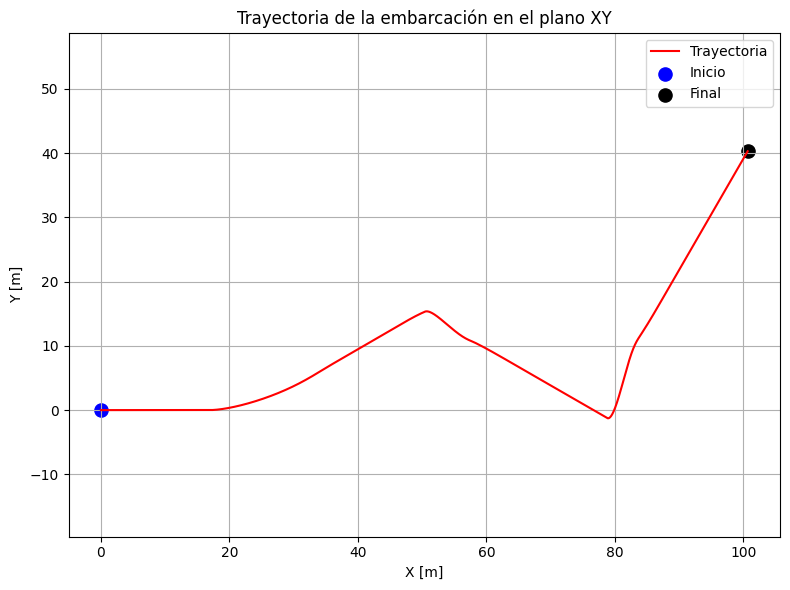

In [11]:
plt.figure(figsize=(8, 6))

plt.plot(X, Y, color="red", linewidth=1.5, label="Trayectoria")
plt.scatter(X[0], Y[0], color="blue", s=90, label="Inicio")
plt.scatter(X[-1], Y[-1], color="black", s=90, label="Final")

plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("Trayectoria de la embarcación en el plano XY")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Parte C

### AVISO
Dejo cosas que van para el informe aca, asi despues me es mas facil hacerlo. Despues veo si las dejo tambien en el notebook o no.

## Ej 1 — Ecuación de estado y función de costo

El sistema aumentado es el mismo de la Parte A. Con $x_a=[v,\ r,\ \psi,\ \xi]^T$,
entrada $u=\tau_r$ y $\dot\xi=\psi_{ref}-\psi=r-Cx$ (integrador del error):

$$\dot x_a = A_a x_a + B_a\,\tau_r + E_a\,\psi_{ref},\qquad
A_a=\begin{bmatrix}A&0\\-C&0\end{bmatrix},\quad
B_a=\begin{bmatrix}B\\0\end{bmatrix},\quad
E_a=\begin{bmatrix}0\\1\end{bmatrix}.$$

La función de costo LQI (horizonte infinito) es:

$$J=\int_0^\infty\big(x_a^T Q_a\,x_a + \tau_r^T R\,\tau_r\big)\,dt,\qquad
Q_a=\begin{bmatrix}Q&0\\0&Q_\xi\end{bmatrix}.$$

- $Q\in\mathbb{R}^{3\times3}$ pondera $[v,r,\psi]$: cuánto penalizamos la desviación de cada estado físico.
- $Q_\xi>0$ pondera el estado integrador $\xi$: a mayor $Q_\xi$, más rápido se elimina el error estacionario.
- $R>0$ es escalar (sistema SISO) y penaliza la magnitud de $\tau_r$. Subir $R$ ⇒ control más suave.

La ley de control es $\tau_r=-K_a x_a=-K_x x - k_i\xi$, con $K_a=R^{-1}B_a^T P$ y $P$ la solución de la ARE.

In [ ]:
from scipy.linalg import solve_continuous_are
from scipy.integrate import trapezoid

# Sistema aumentado (idéntico a la Parte A)
Aa = np.array([
    [-0.25, -2.00,  0.0, 0.0],
    [ 0.08, -0.35,  0.0, 0.0],
    [ 0.00,  1.00,  0.0, 0.0],
    [ 0.00,  0.00, -1.0, 0.0],
])
Ba = np.array([[0.0], [0.62], [0.0], [0.0]])
Ca = np.array([[0.0, 0.0, 1.0, 0.0]])
Da = np.array([[0.0]])
Br = np.array([[0.0], [0.0], [0.0], [1.0]])   # psi_ref entra al integrador

print("Aa =\n", Aa)
print("Ba =\n", Ba.T)

Aa =
 [[-0.25 -2.    0.    0.  ]
 [ 0.08 -0.35  0.    0.  ]
 [ 0.    1.    0.    0.  ]
 [ 0.    0.   -1.    0.  ]]
Ba =
 [[0.   0.62 0.   0.  ]]


## Ej 2 — ¿Se puede aplicar LQI?

Según la teoría, la ARE tiene solución estabilizante única $\bar M\ge0$ si:
1. $(A_a, B_a)$ es **controlable** (o al menos estabilizable), y
2. $(A_a, Q_a^{1/2})$ es **observable** (o al menos detectable).

La controlabilidad ya se verificó en la Parte A. Aquí la volvemos a chequear
y verificamos la detectabilidad asociada a $Q_a$.

In [ ]:
# 1) Controlabilidad del par (Aa, Ba)
Mc = ctrl.ctrb(Aa, Ba)
print("rank(Mc) =", np.linalg.matrix_rank(Mc), " (n = 4)")
print("Controlable:", np.linalg.matrix_rank(Mc) == 4)

# 2) Observabilidad del par (Aa, H) con H = Qa^(1/2)
#    Usamos un Qa de ejemplo
Qa_chk = np.diag([1.0, 1.0, 10.0, 10.0])
H = np.linalg.cholesky(Qa_chk).T          # H^T H = Qa
Mo = ctrl.obsv(Aa, H)
print("rank(Mo) =", np.linalg.matrix_rank(Mo), " (n = 4)")
print("Observable (A, Qa^1/2):", np.linalg.matrix_rank(Mo) == 4)
print("\n=> Se cumplen las condiciones: la ARE tiene solución estabilizante única.")

rank(Mc) = 4  (n = 4)
Controlable: True
rank(Mo) = 4  (n = 4)
Observable (A, Qa^1/2): True

=> Se cumplen las condiciones: la ARE tiene solución estabilizante única.


In [ ]:
def disena_lqi(Qa, R):
    # Resuelve la ARE y devuelve Ka
    P = solve_continuous_are(Aa, Ba, Qa, R)
    Ka = np.linalg.inv(R) @ Ba.T @ P
    return Ka, P

## Ej 3 — Metodología para elegir $Q_a$ y $R$

Como no hay una especificación física dura, la elección se hace **observando el compromiso**
entre esfuerzo de control (pico de $\tau_r$) y velocidad de respuesta (tiempo de asentamiento).
Solo importan los **pesos relativos**, así que fijamos $q_v=1$ y $q_r=1$ como ancla
(la velocidad lateral y la de giro no son objetivos de control) y variamos un parámetro por vez:

- **$R$**: perilla principal del esfuerzo. Subir $R$ ⇒ menor pico de $\tau_r$, respuesta más lenta.
- **$q_\psi$**: peso del rumbo (objetivo de control).
- **$q_\xi$**: peso del integrador; regula qué tan rápido se elimina el error.

Los barridos siguientes hacen visible cada efecto.

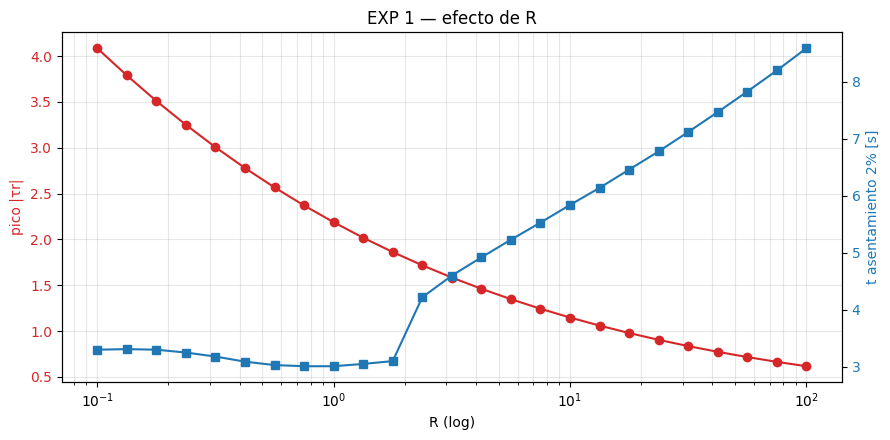

In [ ]:
# Métricas de desempeño para un diseño dado
REF = np.pi/3

def _metricas(Ka):
    A_lc = Aa - Ba @ Ka
    sys = ctrl.ss(A_lc, Br, Ca, Da)
    resp = ctrl.forced_response(sys, T=t, U=psi_ref)
    x = np.asarray(resp.states)
    tau = np.asarray(-Ka @ x).squeeze()
    err = psi_ref - x[2]
    pico = np.max(np.abs(tau))
    tset = np.nan
    for i in np.where(t >= 40)[0]:              # asentamiento 2% del último escalón
        if np.all(np.abs(err[i:]) < 0.02*REF):
            tset = t[i] - 40; break
    return pico, tset

Rs = np.logspace(-1, 2, 25)
Qb = np.diag([1.0, 1.0, 20.0, 50.0])
p1 = [_metricas(disena_lqi(Qb, np.array([[R]]))[0]) for R in Rs]
pico1, tset1 = zip(*p1)

fig, a1 = plt.subplots(figsize=(9, 4.5)); a1.set_xscale("log")
a1.plot(Rs, pico1, 'o-', color="tab:red"); a1.set_xlabel("R (log)")
a1.set_ylabel("pico |τr|", color="tab:red"); a1.tick_params(axis='y', labelcolor="tab:red")
a1.grid(True, which="both", alpha=.3)
a2 = a1.twinx(); a2.plot(Rs, tset1, 's-', color="tab:blue")
a2.set_ylabel("t asentamiento 2% [s]", color="tab:blue"); a2.tick_params(axis='y', labelcolor="tab:blue")
plt.title("EXP 1 — efecto de R"); plt.tight_layout(); plt.show()

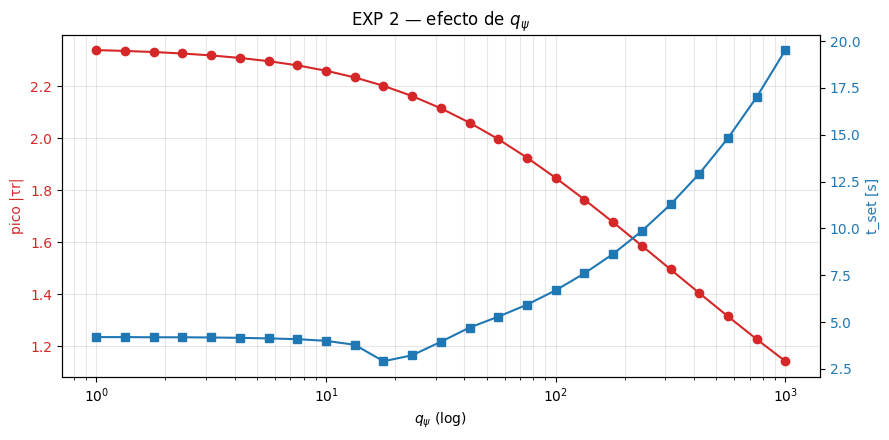

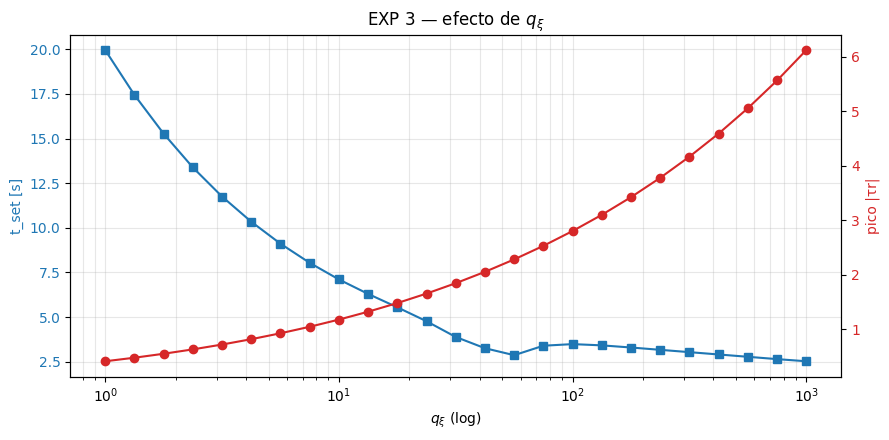

In [ ]:
qpsis = np.logspace(0, 3, 25)
p2 = [_metricas(disena_lqi(np.diag([1,1,q,50.]), np.array([[1.]]))[0]) for q in qpsis]
pico2, tset2 = zip(*p2)

fig, a1 = plt.subplots(figsize=(9, 4.5)); a1.set_xscale("log")
a1.plot(qpsis, pico2, 'o-', color="tab:red"); a1.set_xlabel(r"$q_\psi$ (log)")
a1.set_ylabel("pico |τr|", color="tab:red"); a1.tick_params(axis='y', labelcolor="tab:red")
a1.grid(True, which="both", alpha=.3)
a2 = a1.twinx(); a2.plot(qpsis, tset2, 's-', color="tab:blue")
a2.set_ylabel("t_set [s]", color="tab:blue"); a2.tick_params(axis='y', labelcolor="tab:blue")
plt.title(r"EXP 2 — efecto de $q_\psi$"); plt.tight_layout(); plt.show()

qxis = np.logspace(0, 3, 25)
p3 = [_metricas(disena_lqi(np.diag([1,1,20,q]), np.array([[1.]]))[0]) for q in qxis]
pico3, tset3 = zip(*p3)

fig, a1 = plt.subplots(figsize=(9, 4.5)); a1.set_xscale("log")
a1.plot(qxis, tset3, 's-', color="tab:blue"); a1.set_xlabel(r"$q_\xi$ (log)")
a1.set_ylabel("t_set [s]", color="tab:blue"); a1.tick_params(axis='y', labelcolor="tab:blue")
a1.grid(True, which="both", alpha=.3)
a2 = a1.twinx(); a2.plot(qxis, pico3, 'o-', color="tab:red")
a2.set_ylabel("pico |τr|", color="tab:red"); a2.tick_params(axis='y', labelcolor="tab:red")
plt.title(r"EXP 3 — efecto de $q_\xi$"); plt.tight_layout(); plt.show()

**Conclusiones de los barridos:**
- **EXP 1:** $R$ controla directamente el compromiso. Por debajo de $R\approx1$ el tiempo casi no mejora aunque el esfuerzo crezca mucho (rendimientos decrecientes); rango útil $R\in[1,10]$.
- **EXP 2:** el tiempo es no monótono en $q_\psi$, con un mínimo cerca de $q_\psi\approx20$. Pasarse (>100) empeora tiempo y esfuerzo. Rango sano $q_\psi\in[20,80]$.
- **EXP 3:** $q_\xi$ es lo que más acelera la respuesta (de ~20 s a ~5 s), a costa de mayor pico. Codo en $q_\xi\in[1,50]$.

En todos los casos el pico de $\tau_r$ queda muy por debajo del de la Parte A ($\approx18.6$),
cumpliendo el objetivo de reducir el esfuerzo de control.

## Ej 4 — Diseños representativos y cálculo de $K_a$

A partir de los barridos elegimos **tres puntos representativos de la frontera de Pareto**,
todos con $q_v=q_r=1$ y usando $R$ como eje narrativo (de más a menos esfuerzo penalizado):

| Caso | $Q_a=\mathrm{diag}(v,r,\psi,\xi)$ | $R$ | Rol |
|------|-----------------------------------|-----|------|
| 1 – Suave       | $[1,1,80,5]$  | $9$  | Mínimo esfuerzo, respuesta más lenta |
| 2 – Compromiso  | $[1,1,50,25]$ | $6$   | Balance esfuerzo/velocidad |
| 3 – Rápido      | $[1,1,20,50]$ | $2$ | Prioriza velocidad, más esfuerzo |

Justificación de los pesos: $\psi$ y $\xi$ se ponderan por encima de $v$ y $r$ porque son
el objetivo de control (rumbo) y el mecanismo de error nulo (integrador); $v$ y $r$ quedan en 1
por no ser variables a controlar. La diferencia entre casos es cuánto se penaliza el control vía $R$.

In [ ]:
casos = {
    "Caso 1 (suave)":      (np.diag([1.0, 1.0, 70.0,  5.0]), np.array([[9.0]])),
    "Caso 2 (compromiso)": (np.diag([1.0, 1.0, 50.0, 25.0]), np.array([[6.0]])),
    "Caso 3 (rápido)":     (np.diag([1.0, 1.0, 20.0, 50.0]), np.array([[2.0]])),
}

Ka_casos = {}
for nombre, (Qa, R) in casos.items():
    Ka, P = disena_lqi(Qa, R)
    Ka_casos[nombre] = Ka
    polos = np.linalg.eigvals(Aa - Ba @ Ka)
    print(f"{nombre}")
    print(f"  Ka = {np.round(Ka.flatten(), 3)}")
    print(f"  polos LC = {np.round(np.sort(polos.real), 3)}  (estable: {np.all(polos.real < 0)})\n")

Caso 1 (suave)
  Ka = [ 0.108  2.81   3.614 -0.745]
  polos LC = [-0.92  -0.92  -0.251 -0.251]  (estable: True)

Caso 2 (compromiso)
  Ka = [ 0.114  3.425  5.011 -2.041]
  polos LC = [-0.912 -0.912 -0.647 -0.252]  (estable: True)

Caso 3 (rápido)
  Ka = [ 0.11   4.486  7.874 -5.   ]
  polos LC = [-1.193 -0.969 -0.969 -0.251]  (estable: True)



### Simulación a lazo cerrado (Tf = 60 s, misma $\psi_{ref}$ de la Parte A)

In [ ]:
# Reconstruimos el vector de tiempo y la referencia (por si esta parte se corre sola)
Tf = 60.0
dt = 0.01
t = np.arange(0.0, Tf + dt, dt)
psi_ref = np.select([t < 10.0, t < 25.0, t < 40.0],
                    [0.0, np.pi/6, -np.pi/6], default=np.pi/3)

def simula_lqi(Ka):
    # Simula el lazo cerrado con la referencia entrando por Br. Devuelve x (4xN) y tau_r.
    A_lc = Aa - Ba @ Ka
    sys = ctrl.ss(A_lc, Br, Ca, Da)
    resp = ctrl.forced_response(sys, T=t, U=psi_ref)
    x = np.asarray(resp.states)                 # [v, r, psi, xi]
    tau = np.asarray(-Ka @ x).squeeze()
    return x, tau

sim_casos = {nombre: simula_lqi(Ka) for nombre, Ka in Ka_casos.items()}

# Costo J de cada caso
def costo_J(x, tau, Qa, R):
    integrando = np.einsum('in,ij,jn->n', x, Qa, x) + (tau**2) * R[0, 0]
    return trapezoid(integrando, t)

for nombre, (Qa, R) in casos.items():
    x, tau = sim_casos[nombre]
    J = costo_J(x, tau, Qa, R)
    print(f"{nombre}: pico |tau_r| = {np.max(np.abs(tau)):.2f} | J = {J:.1f}")

Caso 1 (suave): pico |tau_r| = 0.42 | J = 3489.1
Caso 2 (compromiso): pico |tau_r| = 0.96 | J = 5120.6
Caso 3 (rápido): pico |tau_r| = 1.80 | J = 4023.4


## Ej 5 — Comparación LQI vs. Parte A (asignación de polos)

Recalculamos la ganancia de la Parte A ($K_a^{PP}$) y comparamos error de seguimiento,
estados y señal de control

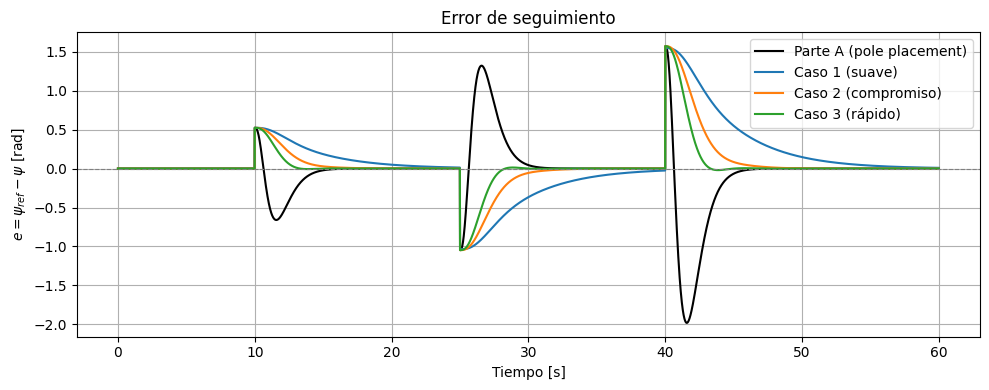

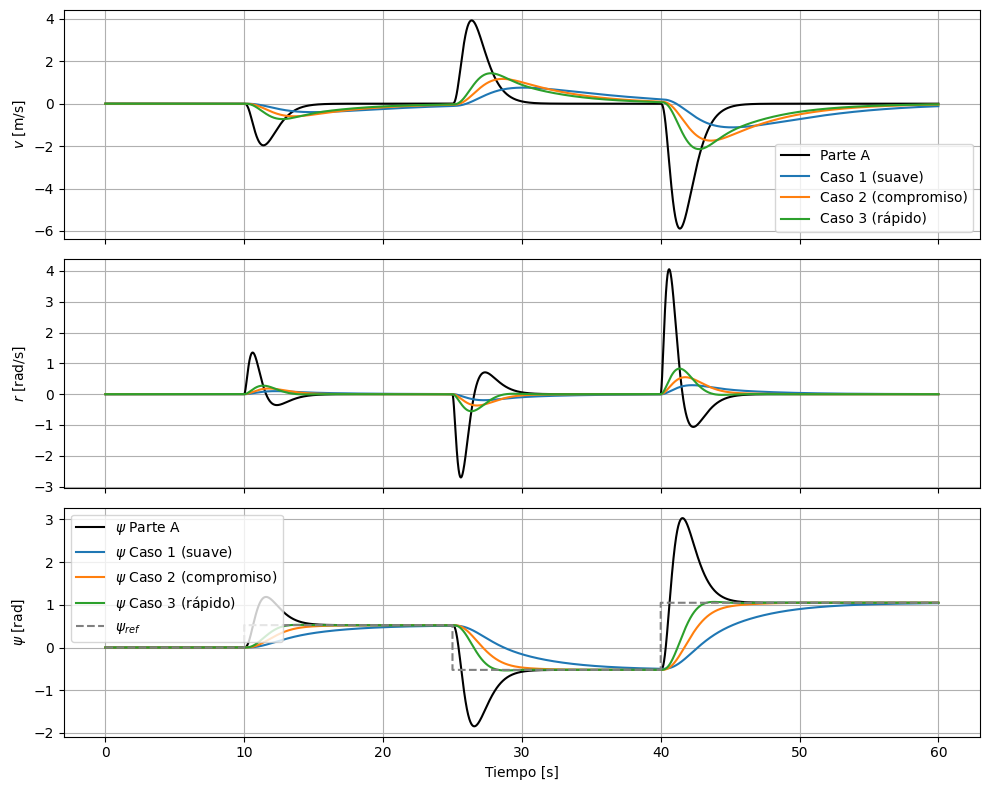

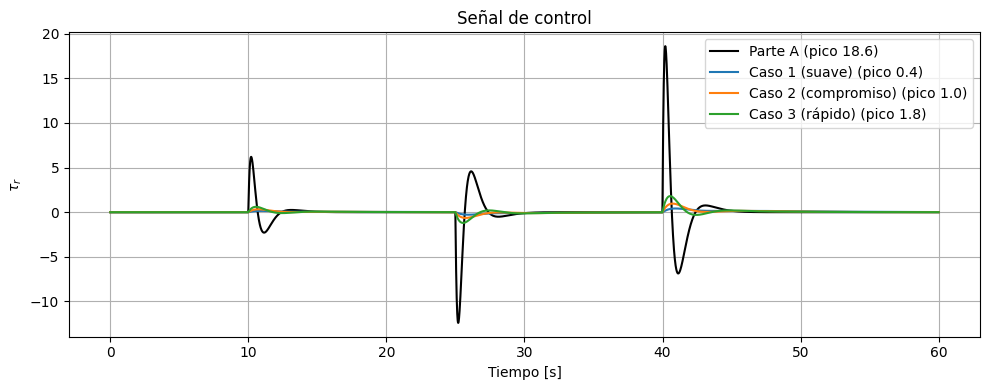

In [ ]:
# --- Ganancia de la Parte A (asignación de polos) ---
n = Aa.shape[0]
Mc_pp = np.hstack([Ba, Aa@Ba, np.linalg.matrix_power(Aa,2)@Ba,
                   np.linalg.matrix_power(Aa,3)@Ba])
phi_A = (np.linalg.matrix_power(Aa,4) + 9.0*np.linalg.matrix_power(Aa,3)
         + 29.75*np.linalg.matrix_power(Aa,2) + 42.75*Aa + 22.5*np.eye(n))
e_n = np.array([[0.0, 0.0, 0.0, 1.0]])
Ka_PP = e_n @ np.linalg.inv(Mc_pp) @ phi_A

# Simulación de la Parte A
x_PP, tau_PP = simula_lqi(Ka_PP)

# Simulación de los TRES casos LQI (dict: nombre -> (x, tau))
sims_lqi = {nombre: simula_lqi(Ka) for nombre, Ka in Ka_casos.items()}

plt.figure(figsize=(10, 4))
plt.plot(t, psi_ref - x_PP[2], color="black", lw=1.5, label="Parte A (pole placement)")
for nombre, (x, tau) in sims_lqi.items():
    plt.plot(t, psi_ref - x[2], label=nombre)
plt.axhline(0.0, color="gray", lw=0.8, ls="--")
plt.xlabel("Tiempo [s]"); plt.ylabel(r"$e=\psi_{ref}-\psi$ [rad]")
plt.title("Error de seguimiento"); plt.grid(True); plt.legend(); plt.tight_layout()

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
ax[0].plot(t, x_PP[0], color="black", label="Parte A")
for nombre, (x, tau) in sims_lqi.items():
    ax[0].plot(t, x[0], label=nombre)
ax[0].set_ylabel(r"$v$ [m/s]"); ax[0].grid(True); ax[0].legend()

ax[1].plot(t, x_PP[1], color="black")
for nombre, (x, tau) in sims_lqi.items():
    ax[1].plot(t, x[1])
ax[1].set_ylabel(r"$r$ [rad/s]"); ax[1].grid(True)

ax[2].plot(t, x_PP[2], color="black", label=r"$\psi$ Parte A")
for nombre, (x, tau) in sims_lqi.items():
    ax[2].plot(t, x[2], label=rf"$\psi$ {nombre}")
ax[2].step(t, psi_ref, where="post", ls="--", color="gray", label=r"$\psi_{ref}$")
ax[2].set_ylabel(r"$\psi$ [rad]"); ax[2].set_xlabel("Tiempo [s]")
ax[2].grid(True); ax[2].legend(); fig.tight_layout()


plt.figure(figsize=(10, 4))
plt.plot(t, tau_PP, color="black", lw=1.5,
         label=f"Parte A (pico {np.max(np.abs(tau_PP)):.1f})")
for nombre, (x, tau) in sims_lqi.items():
    plt.plot(t, tau, label=f"{nombre} (pico {np.max(np.abs(tau)):.1f})")
plt.xlabel("Tiempo [s]"); plt.ylabel(r"$\tau_r$")
plt.title("Señal de control"); plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

## Ej 6 — Reconstrucción de la trayectoria XY (LQI)

Integramos las ecuaciones cinemáticas (13)-(14) usando $v(t)$ y $\psi(t)$ del controlador LQI,
igual que en la Parte B.

In [ ]:
u0 = 2.0
def trayectoria_xy(x_estados):
    # Integra X,Y a partir de v(t) y psi(t) de una simulación.
    v_i   = interp1d(t, x_estados[0, :], kind="linear", fill_value="extrapolate")
    psi_i = interp1d(t, x_estados[2, :], kind="linear", fill_value="extrapolate")

    def cinematica(ti, pos):
        vt, pt = float(v_i(ti)), float(psi_i(ti))
        return [u0*np.cos(pt) - vt*np.sin(pt),
                u0*np.sin(pt) + vt*np.cos(pt)]

    sol = solve_ivp(cinematica, [t[0], t[-1]], [0.0, 0.0], t_eval=t)
    return sol.y[0], sol.y[1]

# Trayectoria de la Parte A
X_PP, Y_PP = trayectoria_xy(x_PP)

# Trayectoria de los TRES casos LQI (dict: nombre -> (X, Y))
trays_lqi = {nombre: trayectoria_xy(x) for nombre, (x, tau) in sims_lqi.items()}

print(f"Parte A -> fin ({X_PP[-1]:.1f}, {Y_PP[-1]:.1f})")
for nombre, (X, Y) in trays_lqi.items():
    print(f"{nombre} -> fin ({X[-1]:.1f}, {Y[-1]:.1f})")


Parte A -> fin (100.7, 40.3)
Caso 1 (suave) -> fin (113.4, 22.6)
Caso 2 (compromiso) -> fin (109.8, 27.1)
Caso 3 (rápido) -> fin (109.1, 28.2)


## Ej 7 — Trayectorias XY: Parte A vs. Parte C

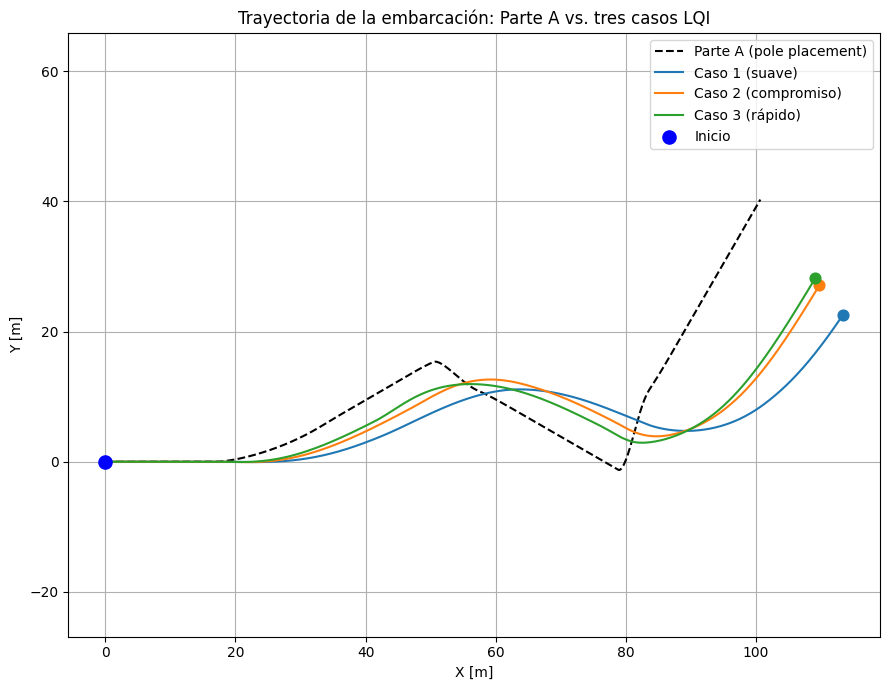

In [ ]:
# --- Gráfico ---
plt.figure(figsize=(9, 7))
plt.plot(X_PP, Y_PP, color="black", lw=1.5, ls="--", label="Parte A (pole placement)")
for nombre, (X, Y) in trays_lqi.items():
    plt.plot(X, Y, lw=1.5, label=nombre)

plt.scatter(0, 0, color="blue", s=90, zorder=5, label="Inicio")
for nombre, (X, Y) in trays_lqi.items():
    plt.scatter(X[-1], Y[-1], s=60, zorder=5)   # marca el final de cada LQI

plt.xlabel("X [m]"); plt.ylabel("Y [m]")
plt.title("Trayectoria de la embarcación: Parte A vs. tres casos LQI")
plt.axis("equal"); plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

## Ej 8 — Discusión: pole placement vs. LQI

**Asignación de polos (Parte A)**
- *Ventajas:* 
- *Desventajas:* 

**LQI (Parte C)**
- *Ventajas:* optimiza un compromiso explícito estados/control vía $Q_a$ y $R$. Reduce drásticamente el pico de $\tau_r$ (a ~0.96 en el caso de compromiso) manteniendo seguimiento sin error estacionario gracias al integrador. Estabilidad garantizada bajo controlabilidad + detectabilidad. Escala naturalmente a MIMO.
- *Desventajas:* no fija los polos directamente (la dinámica resultante es indirecta); requiere iterar sobre $Q_a$ y $R$. El $R$ grande que suaviza el control también hace la respuesta más lenta (trade-off velocidad/esfuerzo).

**Conclusión:**  TENTATIVO   para este problema LQI es preferible porque logra el mismo seguimiento
con un esfuerzo de control mucho más compatible con las limitaciones físicas del actuador.